# Credit Risk & Decision Process Exploration

Exploratory analysis of the Chevron Constantine Banking synthetic credit application
portfolio. This notebook does not introduce new logic: every KPI and grouping it
uses comes from `python/analysis.py` and `python/risk_analysis.py`, so the numbers
here match the SQL queries in `sql/` and the eventual dashboard exactly (see
`docs/methodology.md`). Its job is to walk through the findings visually and narrate
them, not to redefine anything.

Each analysis below follows the same structure: **Observation -> Evidence ->
Interpretation -> Business implication.**

## 1. Business context

Chevron Constantine Banking's credit department wants a clear, evidence-based view of
what drives processing delays and where the process could be made more efficient
without weakening its risk controls. Full framing:
`business-analysis/project-brief.md`. Full question list:
`business-analysis/business-questions.md`.

Reminder before looking at any number: this dataset is synthetic, and every
relationship in it was simulated on purpose (see `docs/assumptions.md`). Findings
below describe *associations in this dataset*, not proven causes, and not a real
credit risk model.

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent / "python"))

import matplotlib.pyplot as plt
import pandas as pd

from analysis import (
    load_clean_data,
    portfolio_kpi_summary,
    processing_time_by_manual_review,
    processing_time_by_channel,
    verification_errors_vs_processing_time,
    manual_review_rate_by_segment,
    manual_review_outcome_breakdown,
    kpi_by_loan_size_band,
)
from risk_analysis import (
    profile_by_decision_path,
    dti_band_vs_decision,
    previous_defaults_vs_decision,
    income_to_amount_ratio_vs_decision,
    documents_complete_vs_decision,
)

plt.rcParams["figure.figsize"] = (7, 4)
df = load_clean_data()
df.shape

(19980, 23)

## 2. Dataset overview

One row per credit application, 20,080 generated, 19,980 remaining after cleaning
(100 rows removed: 80 exact duplicates, 20 business-rule violations - see
`python/data_cleaning.py`).

In [2]:
df.dtypes

application_id                   object
customer_id                      object
application_date         datetime64[ns]
channel                          object
customer_segment                 object
age_group                        object
employment_status                object
annual_income                   float64
monthly_expenses                float64
existing_loans                    int64
requested_amount                float64
loan_term_months                  int64
debt_to_income_ratio            float64
credit_history_length           float64
previous_defaults                 int64
documents_complete                 bool
verification_errors               int64
manual_review                      bool
processing_time_hours           float64
decision                         object
decision_reason                  object
application_status               object
annual_income_imputed              bool
dtype: object

In [3]:
df.head()

,application_id,customer_id,application_date,channel,customer_segment,age_group,employment_status,annual_income,monthly_expenses,existing_loans,...,credit_history_length,previous_defaults,documents_complete,verification_errors,manual_review,processing_time_hours,decision,decision_reason,application_status,annual_income_imputed
0,APP-016799,CUST-016799,2026-03-10,phone,self_employed,46-55,employed,49455.38,1616.88,0,...,5.8,1,True,0,False,24.5,approved,acceptable debt-to-income ratio,completed,False
1,APP-005149,CUST-005149,2025-10-24,broker,retail_affluent,36-45,employed,108279.47,6242.15,0,...,18.4,0,True,0,True,79.4,approved,clean credit history,completed,False
2,APP-017970,CUST-017970,2026-06-16,online,retail_affluent,26-35,employed,78576.81,3799.15,0,...,4.6,0,True,0,True,98.1,approved,acceptable debt-to-income ratio,completed,False
3,APP-008732,CUST-008732,2025-07-29,broker,retail_mass,56-65,employed,57877.88,3830.07,2,...,39.2,0,True,1,False,18.5,approved,stable income relative to requested amount,completed,False
4,APP-005865,CUST-005865,2025-11-03,online,retail_mass,26-35,employed,50771.70,1943.67,2,...,11.9,0,True,1,False,23.2,approved,acceptable debt-to-income ratio,completed,False


## 3. Data quality

Handled in `python/data_cleaning.py`, not repeated here. Three distinct situations,
three different treatments:

- `decision` is missing for withdrawn applications - a structural null, not a defect.
- `annual_income` (300 rows) was imputed with the median income for the same
  `employment_status`.
- `employment_status` (200 rows) was recoded to an explicit `"unknown"` category.

The only column that should still show missing values below is `decision`.

In [4]:
df.isna().sum()[df.isna().sum() > 0]

decision    587
dtype: int64

## 4. Portfolio KPIs

**Observation:** the portfolio-level numbers, in one place.

In [5]:
summary = portfolio_kpi_summary(df)
summary

total_applications              19980.000000
approval_rate                       0.893879
rejection_rate                      0.106121
withdrawal_rate                     0.029379
manual_review_rate                  0.155305
avg_processing_time_hours          34.273819
median_processing_time_hours       22.600000
p90_processing_time_hours          85.510000
avg_requested_amount            52818.771356
incomplete_application_rate         0.158659
avg_verification_errors             0.629429
dtype: float64

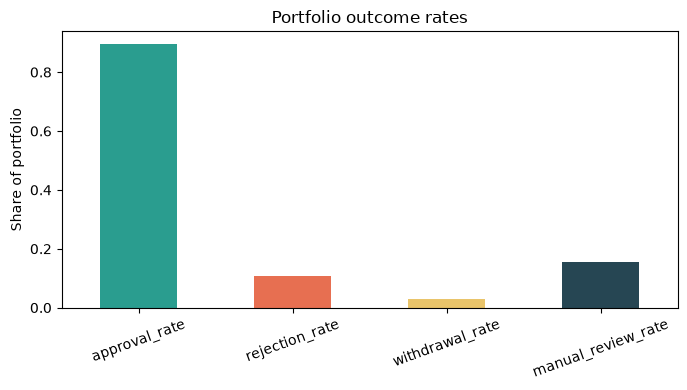

In [6]:
rates = summary[["approval_rate", "rejection_rate", "withdrawal_rate", "manual_review_rate"]]
rates.plot(kind="bar", legend=False, color=["#2a9d8f", "#e76f51", "#e9c46a", "#264653"])
plt.ylabel("Share of portfolio")
plt.title("Portfolio outcome rates")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**Evidence:** approval rate ~89%, rejection ~11% (of decided applications),
manual review touches roughly 1 in 6 applications, and withdrawal - a customer
pulling out before any decision - sits at ~3%.

**Interpretation:** the portfolio is not dominated by rejections; the more
interesting story is *how long it takes to reach a decision at all*, which the next
sections dig into.

**Business implication:** approval/rejection rate alone would not have surfaced the
manual review or withdrawal pattern - both matter more for the "make the process
faster" objective than the accept/reject split itself.

## 5. Decision analysis

**Observation:** comparing applicant profiles across three decision paths:
`manual_review` (regardless of eventual outcome), `approved`, `rejected`, and
`withdrawn` (see `risk_analysis.decision_path_category` for why manual review is
kept as its own bucket rather than folded into approved/rejected).

In [7]:
profile_by_decision_path(df)

,count,avg_annual_income,avg_monthly_expenses,avg_debt_to_income_ratio,avg_requested_amount,avg_previous_defaults,incomplete_document_rate
decision_path,,,,,,,
approved,15076,48027.078970,2384.896427,0.266935,49351.350205,0.061289,0.091006
manual_review,3103,58630.362317,2973.867989,0.275833,71850.598688,0.162746,0.466967
rejected,1643,43867.346172,2303.689306,0.310515,48900.310791,0.257456,0.203895
withdrawn,158,52594.051962,2626.822658,0.263658,50648.592722,0.056962,0.088608


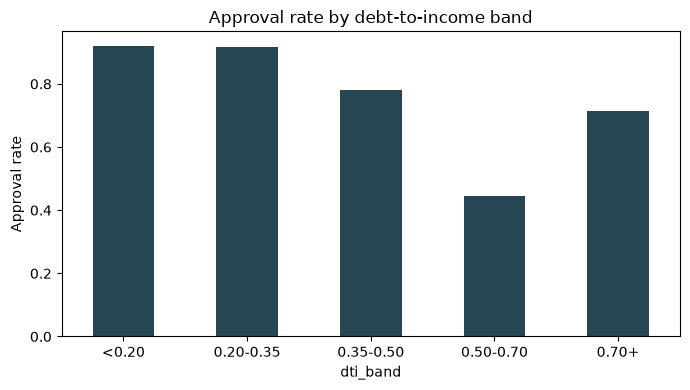

In [8]:
dti_band_vs_decision(df).plot(kind="bar", color="#264653")
plt.ylabel("Approval rate")
plt.title("Approval rate by debt-to-income band")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Evidence:** approval rate declines from ~92% for DTI under 0.20 to ~78% for
0.35-0.50. The last two bands (0.50-0.70 and 0.70+) have very few applications
(126 and 15 respectively) and their rates should be read with that in mind - this
is exactly the kind of small-sample caveat a Business Analyst should flag rather
than quote as a clean trend.

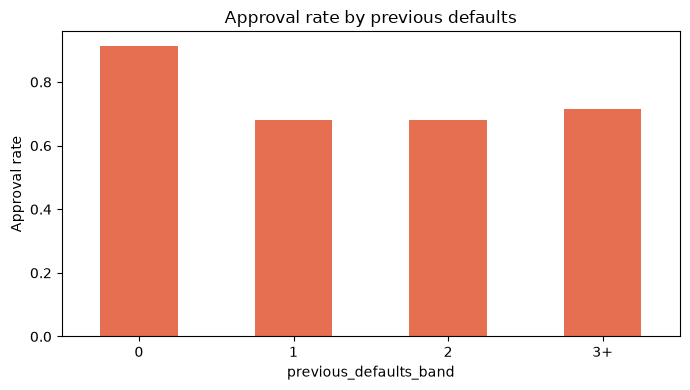

In [9]:
previous_defaults_vs_decision(df).plot(kind="bar", color="#e76f51")
plt.ylabel("Approval rate")
plt.title("Approval rate by previous defaults")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

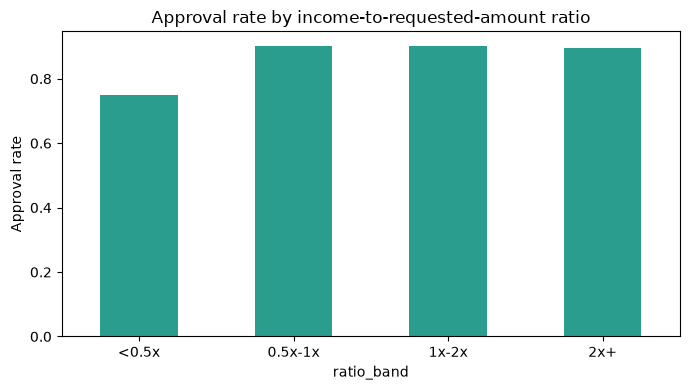

In [10]:
income_to_amount_ratio_vs_decision(df).plot(kind="bar", color="#2a9d8f")
plt.ylabel("Approval rate")
plt.title("Approval rate by income-to-requested-amount ratio")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Interpretation:** having at least one previous default is associated with a
sharp drop in approval rate (from ~91% to ~68%), while a second or third default adds
little further difference in this dataset - the drop is concentrated at "any history
of default" rather than scaling with the count. A low income-to-requested-amount
ratio (under 0.5x) is associated with the lowest approval rate observed for any
factor in this analysis.

**Business implication:** if this pattern held in a real portfolio, it would suggest
prioritizing a clean affordability check (income relative to amount requested) and a
default-history flag early in the process, since they show the strongest
association with the final decision here.

## 6. Processing time

**Observation:** where the time actually goes.

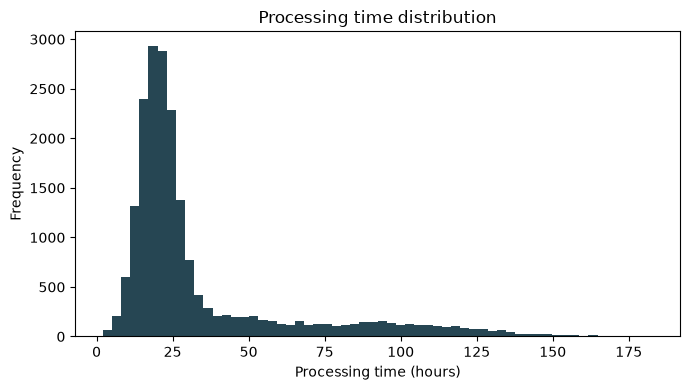

In [11]:
df["processing_time_hours"].plot(kind="hist", bins=60, color="#264653")
plt.xlabel("Processing time (hours)")
plt.title("Processing time distribution")
plt.tight_layout()
plt.show()

In [12]:
processing_time_by_manual_review(df)

,mean,median,p90,count
manual_review,,,,
False,23.012390,20.9,34.7,16877
True,95.523945,94.4,130.3,3103


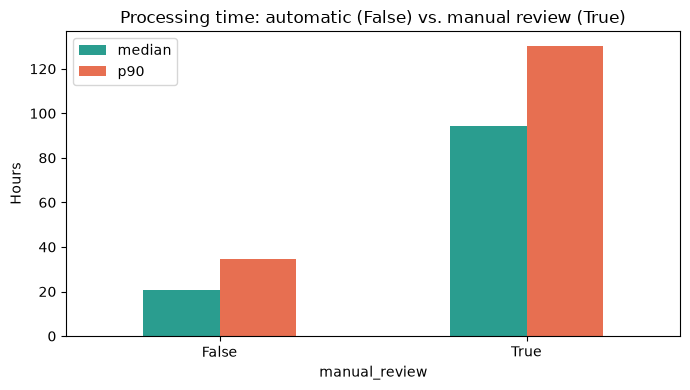

In [13]:
processing_time_by_manual_review(df)[["median", "p90"]].plot(kind="bar", color=["#2a9d8f", "#e76f51"])
plt.ylabel("Hours")
plt.title("Processing time: automatic (False) vs. manual review (True)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Evidence:** median processing time is 20.9 hours for automatically decided
applications versus 94.4 hours when manual review is involved - a ~4.5x difference,
and the p90 gap is even larger (34.7h vs 130.3h).

In [14]:
processing_time_by_channel(df)

,mean,median,p90,count
channel,,,,
phone,38.244657,27.7,82.07,992
broker,32.923090,23.2,75.45,3036
mobile_app,35.657005,23.0,88.80,4854
online,36.964783,22.9,93.30,6971
branch,28.140804,19.7,66.28,4127


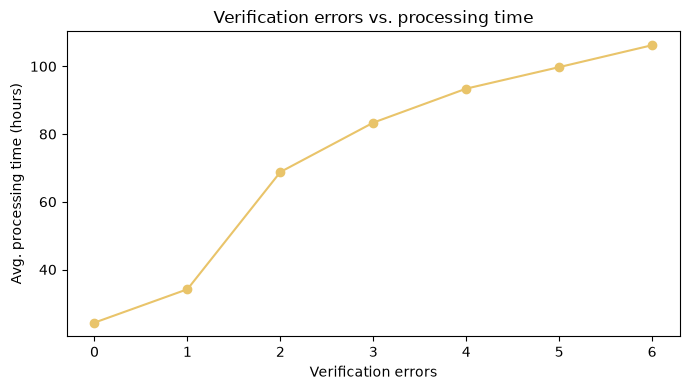

In [15]:
verification_errors_vs_processing_time(df)["mean"].plot(kind="line", marker="o", color="#e9c46a")
plt.xlabel("Verification errors")
plt.ylabel("Avg. processing time (hours)")
plt.title("Verification errors vs. processing time")
plt.tight_layout()
plt.show()

**Interpretation:** manual review is, by a wide margin, the single largest driver
of processing time in this dataset - larger than any channel effect. The
relationship between verification errors and processing time looks close to
monotonic: each additional error is associated with more time, not just crossing a
single threshold.

**Business implication:** any effort to reduce average processing time should target
*why* applications reach manual review in the first place (see Section 7), not just
try to speed up the manual review step itself.

## 7. Manual review

**Observation:** who ends up in manual review, and what actually happens to them
there.

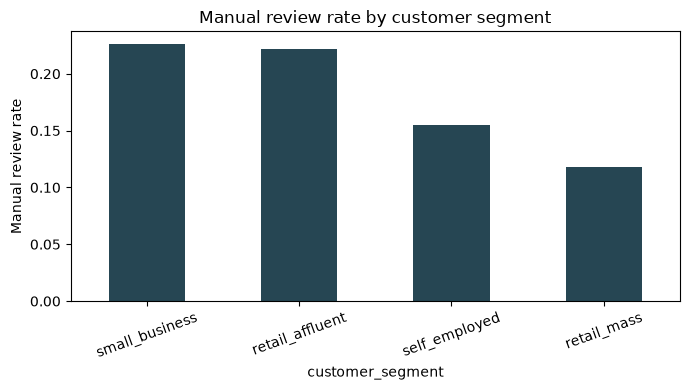

In [16]:
manual_review_rate_by_segment(df).plot(kind="bar", color="#264653")
plt.ylabel("Manual review rate")
plt.title("Manual review rate by customer segment")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

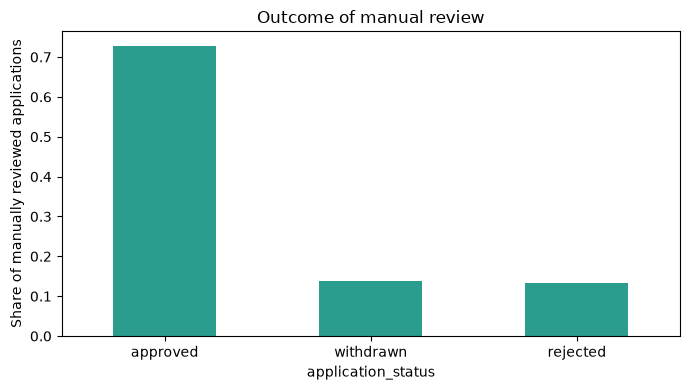

In [17]:
manual_review_outcome_breakdown(df).plot(kind="bar", color="#2a9d8f")
plt.ylabel("Share of manually reviewed applications")
plt.title("Outcome of manual review")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Evidence:** small business and retail affluent customers see manual review
rates around 22%, roughly double the retail mass segment (~12%). Of the applications
that reach manual review, 73% are still approved, 13% are rejected, and 14% are
withdrawn by the customer before a decision is reached.

**Interpretation:** manual review is not a rubber stamp (it does produce a
meaningfully different rejection outcome than the portfolio average), but the 14%
withdrawal rate is a real cost: some customers are not being rejected by the
process, they are giving up on it. Framed as an automation-vs-control question
(never "should we remove manual review"): the 73% approval share suggests a
meaningful share of manually reviewed files could plausibly be pre-screened with a
lighter check, while the 13% rejection share is evidence the human step is still
catching real cases automation should not swallow blind.

**Business implication:** the highest-leverage fix for this pain point is probably
not shortening the manual review step itself, but reducing *how many* files land in
it unnecessarily, and giving customers visibility into wait times so fewer withdraw
out of uncertainty rather than an actual negative decision.

## 8. Segmentation

**Observation:** requested amount and processing time together, split by whether
the application needed manual review.

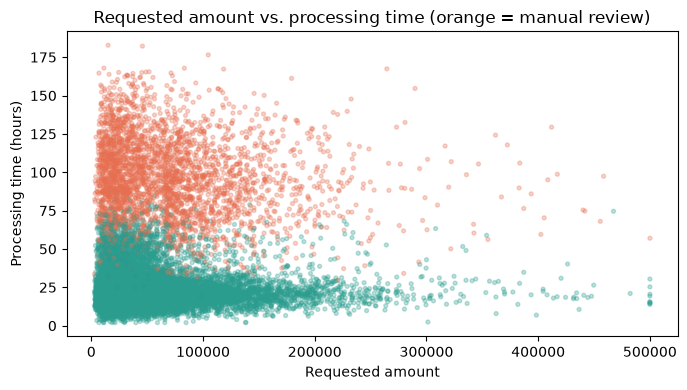

In [18]:
colors = df["manual_review"].map({True: "#e76f51", False: "#2a9d8f"})
plt.scatter(df["requested_amount"], df["processing_time_hours"], c=colors, alpha=0.3, s=8)
plt.xlabel("Requested amount")
plt.ylabel("Processing time (hours)")
plt.title("Requested amount vs. processing time (orange = manual review)")
plt.tight_layout()
plt.show()

In [19]:
kpi_by_loan_size_band(df)[["manual_review_rate", "avg_processing_time_hours"]]

,manual_review_rate,avg_processing_time_hours
loan_size_band,,
25k-50k,0.107930,31.370055
10k-25k,0.110449,31.447141
50k-100k,0.204515,37.297831
100k+,0.291129,42.483001
<10k,0.135729,33.748902


**Evidence:** manual review rate rises from ~11% for loans under 25k to ~29% for
loans of 100k or more, and average processing time follows the same shape.

**Interpretation:** loan size is associated with complexity (larger loans get more
scrutiny), which shows up as more manual review and longer processing time - this is
a control working as intended, not a friction point to remove.

**Business implication:** any future automation should be targeted at *smaller,
simpler* files first, where the manual review rate is already relatively low and the
marginal risk of lighter-touch automation is smaller.

## 9. Data completeness

**Observation:** incomplete documentation is one of the strongest signals in this
whole analysis.

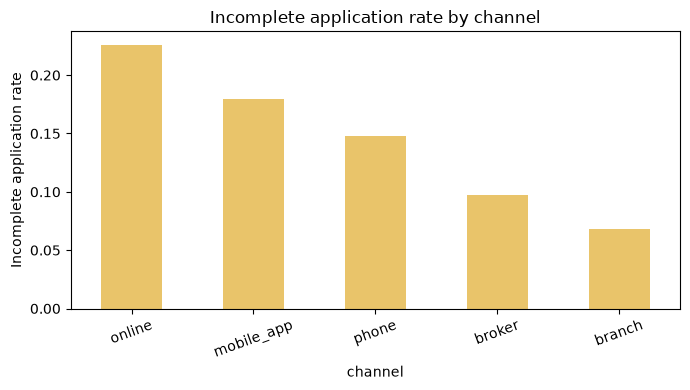

In [20]:
df.groupby("channel")["documents_complete"].apply(lambda s: (~s).mean()).sort_values(ascending=False).plot(
    kind="bar", color="#e9c46a"
)
plt.ylabel("Incomplete application rate")
plt.title("Incomplete application rate by channel")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [21]:
documents_complete_vs_decision(df)

documents_complete
False    0.802957
True     0.909918
Name: decision, dtype: float64

**Evidence:** fully digital channels (online, mobile app) show a higher
incomplete-application rate than in-person channels (branch, broker), matching how
`documents_complete` was simulated (see `docs/assumptions.md`). Incomplete
applications are also strongly overrepresented in the manual review population
(47% incomplete vs. 10% for automatically approved applications, Section 5's profile
table) and show a lower approval rate (80% vs. 91%).

**Interpretation:** document completeness at intake is one of the most consistent
signals in this dataset - it shows up in manual review rate, processing time, and
approval rate alike.

**Business implication:** catching missing documents *before* submission (clearer
upload guidance, real-time validation on digital channels) is one of the few changes
that plausibly improves several KPIs at once, rather than trading one off against
another.

## 10. Key findings

1. Manual review is associated with a ~4.5x increase in median processing time
   (94.4h vs. 20.9h), more than any channel or segment effect observed.
2. Of applications reaching manual review, 14% end in the customer withdrawing
   before a decision - a cost of the process itself, not of the underlying risk.
3. Document completeness at intake is associated with manual review rate,
   processing time, and approval rate simultaneously.
4. A history of previous defaults is associated with a sharp drop in approval rate
   (91% to 68%), but the drop does not scale further with additional defaults in
   this dataset.
5. Manual review rate and processing time both scale with requested loan amount,
   consistent with larger loans receiving more scrutiny by design.

Full detail, evidence, and recommendations for each: `docs/final-report.md`.

## 11. Business implications

Taken together, these findings point at delay as a *process design* problem more
than a *risk* problem: the applications that take the longest are not necessarily
the riskiest ones, they are the ones missing information at intake or sized large
enough to trigger a manual step. Improving document completeness upfront and giving
customers visibility during manual review would very plausibly reduce both average
processing time and the withdrawal rate, without touching the risk controls
themselves.

## 12. Recommendations

Recommendations, prioritized by impact and effort, with the KPI each one should
move, are developed in full in `docs/final-report.md` (Phase 9-10 of this project).
This notebook stops at the evidence; turning evidence into a prioritized roadmap is
a separate step, deliberately.